In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (9,5)
plt.rcParams["axes.grid"] = True

In [2]:
csv_path = "Datos_de_Estaciones_de_IDEAM_y_de_Terceros_20250902.csv"

dtypes = {
    "CodigoEstacion": "string",
    "CodigoSensor": "string",
    "FechaObservacion": "string",
    "ValorObservado": "string",
    "NombreEstacion": "string",
    "Departamento": "string",
    "Municipio": "string",
    "ZonaHidrografica": "string",
    "Latitud": "float64",
    "Longitud": "float64",
    "DescripcionSensor": "string",
    "UnidadMedida": "string",
    "Entidad": "string",
}

df = pd.read_csv(csv_path, dtype=dtypes)

In [3]:
# Fecha a datetime (maneja formatos tipo "2025 Sep 01 04:02:00 AM")
df["FechaObservacion"] = pd.to_datetime(df["FechaObservacion"], errors="coerce")

# Valor observado a float (quita comas de miles)
df["ValorObservado"] = (
    df["ValorObservado"].astype(str).str.replace(",", "", regex=False).str.strip()
)
df["ValorObservado"] = pd.to_numeric(df["ValorObservado"], errors="coerce")

# Normaliza etiquetas
for c in ["DescripcionSensor", "NombreEstacion", "Departamento", "Municipio", "ZonaHidrografica", "UnidadMedida", "Entidad"]:
    df[c] = df[c].str.strip()

# Quita filas sin fecha o valor numérico
df = df.dropna(subset=["FechaObservacion", "ValorObservado"]).copy()

# (Opcional) Convierte columnas de texto muy repetidas a 'category' para ahorrar memoria
for c in ["DescripcionSensor", "NombreEstacion", "Departamento", "Municipio", "ZonaHidrografica", "UnidadMedida", "Entidad"]:
    df[c] = df[c].astype("category")


In [4]:
print("\n--- info ---")
print(df.info())
print("\n--- describe ValorObservado por sensor ---")
print(df.groupby("DescripcionSensor")["ValorObservado"].agg(["count","mean","min","max"]).sort_values("count", ascending=False).round(3).head(20))

print("\n--- Top 10 estaciones con más registros ---")
top_estaciones = df["NombreEstacion"].value_counts().head(10)
print(top_estaciones)

print("\n--- Top sensores por cantidad de registros ---")
top_sensores = df["DescripcionSensor"].value_counts()
print(top_sensores)


--- info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554828 entries, 0 to 554827
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   CodigoEstacion     554828 non-null  string        
 1   CodigoSensor       554828 non-null  string        
 2   FechaObservacion   554828 non-null  datetime64[ns]
 3   ValorObservado     554828 non-null  float64       
 4   NombreEstacion     554828 non-null  category      
 5   Departamento       554828 non-null  category      
 6   Municipio          554828 non-null  category      
 7   ZonaHidrografica   554828 non-null  category      
 8   Latitud            554828 non-null  float64       
 9   Longitud           554828 non-null  float64       
 10  DescripcionSensor  554828 non-null  category      
 11  UnidadMedida       554828 non-null  category      
 12  Entidad            554828 non-null  category      
dtypes: category(7), datetime64[ns]

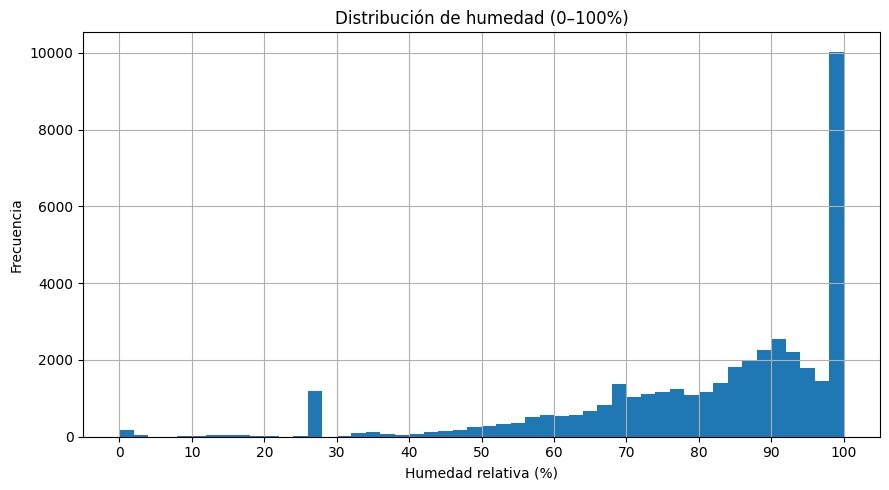

In [5]:
hum = df[df["DescripcionSensor"].str.contains("HUMEDAD", case=False, na=False)].copy()
hum = hum[hum["ValorObservado"].between(0, 100)]

bins = np.arange(0, 101, 2)
plt.figure()
plt.hist(hum["ValorObservado"], bins=bins)
plt.title("Distribución de humedad (0–100%)")
plt.xlabel("Humedad relativa (%)")
plt.ylabel("Frecuencia")
plt.xticks(np.arange(0, 101, 10))
plt.tight_layout()
plt.show()

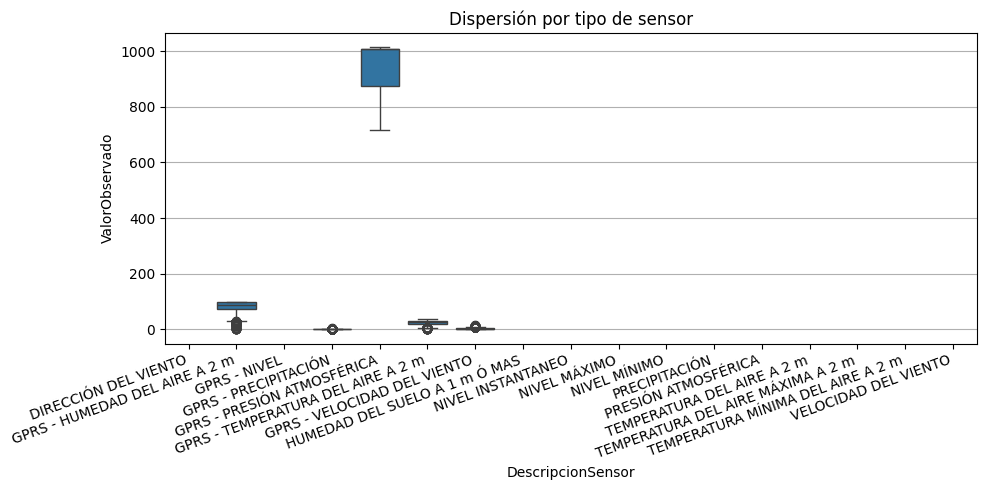

In [6]:
#    Para evitar mezclar unidades distintas, selecciona algunos sensores homogéneos
sensores_plot = [
    "GPRS - TEMPERATURA DEL AIRE A 2 m",
    "GPRS - HUMEDAD DEL AIRE A 2 m",
    "GPRS - VELOCIDAD DEL VIENTO",
    "GPRS - PRESIÓN ATMOSFÉRICA",
    "GPRS - PRECIPITACIÓN",
]
df_box = df[df["DescripcionSensor"].isin(sensores_plot)].copy()
plt.figure(figsize=(10,5))
sns.boxplot(data=df_box, x="DescripcionSensor", y="ValorObservado")
plt.xticks(rotation=20, ha="right")
plt.title("Dispersión por tipo de sensor")
plt.tight_layout()
plt.show()

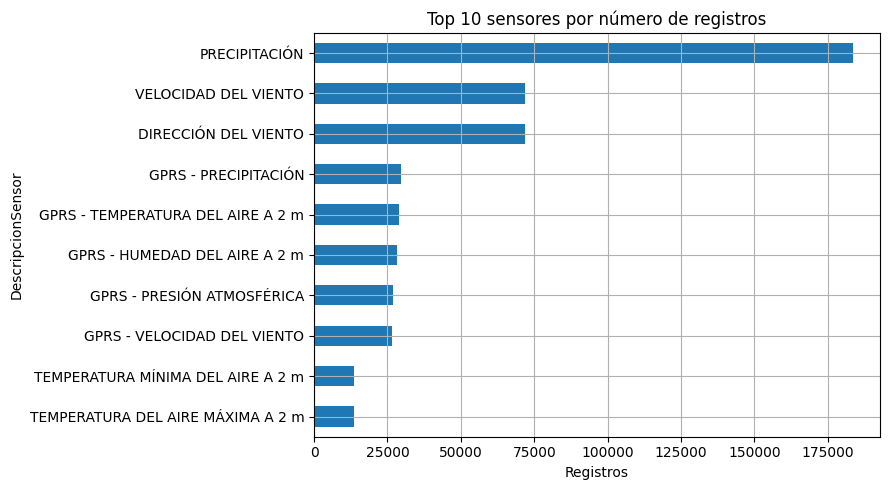

In [7]:
plt.figure()
top_sensores.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 sensores por número de registros")
plt.xlabel("Registros")
plt.tight_layout()
plt.show()

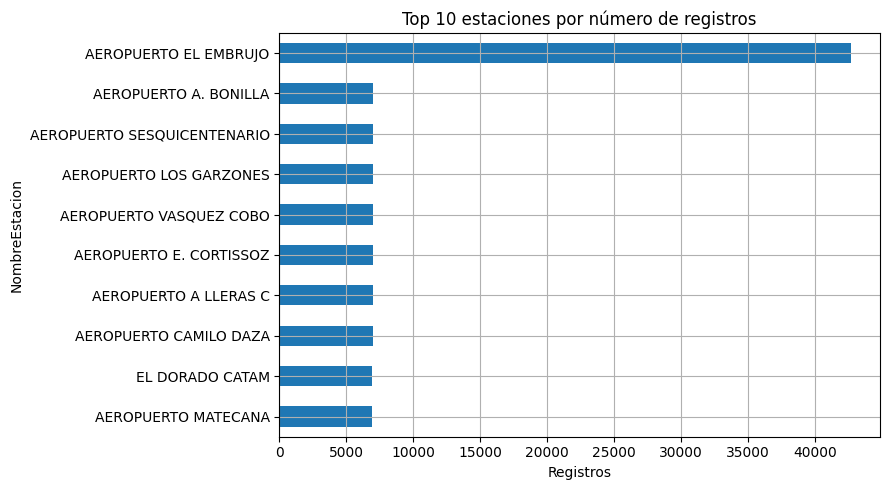

In [8]:
plt.figure()
top_estaciones.sort_values().plot(kind="barh")
plt.title("Top 10 estaciones por número de registros")
plt.xlabel("Registros")
plt.tight_layout()
plt.show()


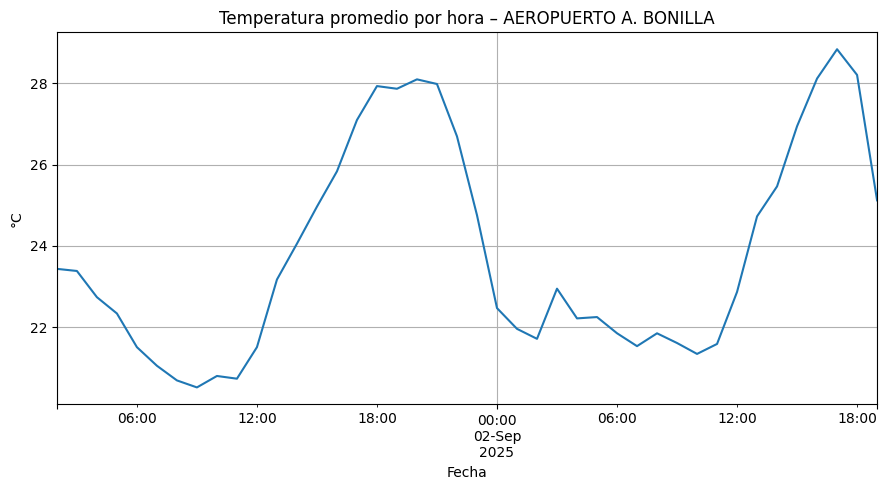

In [9]:
# 5.1 Temperatura por estación específica (cambia el nombre si quieres otra)
estacion_ej = "AEROPUERTO A. BONILLA"
temp = df[
    (df["NombreEstacion"] == estacion_ej)
    & (df["DescripcionSensor"].str.contains("TEMPERATURA", case=False, na=False))
].set_index("FechaObservacion").sort_index()

temp_h = temp["ValorObservado"].resample("1H").mean()

plt.figure()
temp_h.plot()
plt.title(f"Temperatura promedio por hora – {estacion_ej}")
plt.xlabel("Fecha")
plt.ylabel("°C")
plt.tight_layout()
plt.show()


In [10]:
# 5.2 Precipitación acumulada mensual por departamento (top N)
prec = df[df["DescripcionSensor"].str.contains("PRECIPITACIÓN", case=False, na=False)].copy()
prec["fecha_mes"] = df["FechaObservacion"].dt.to_period("M").dt.to_timestamp()
acc_mes_depto = prec.groupby(["Departamento", "fecha_mes"])["ValorObservado"].sum().reset_index()


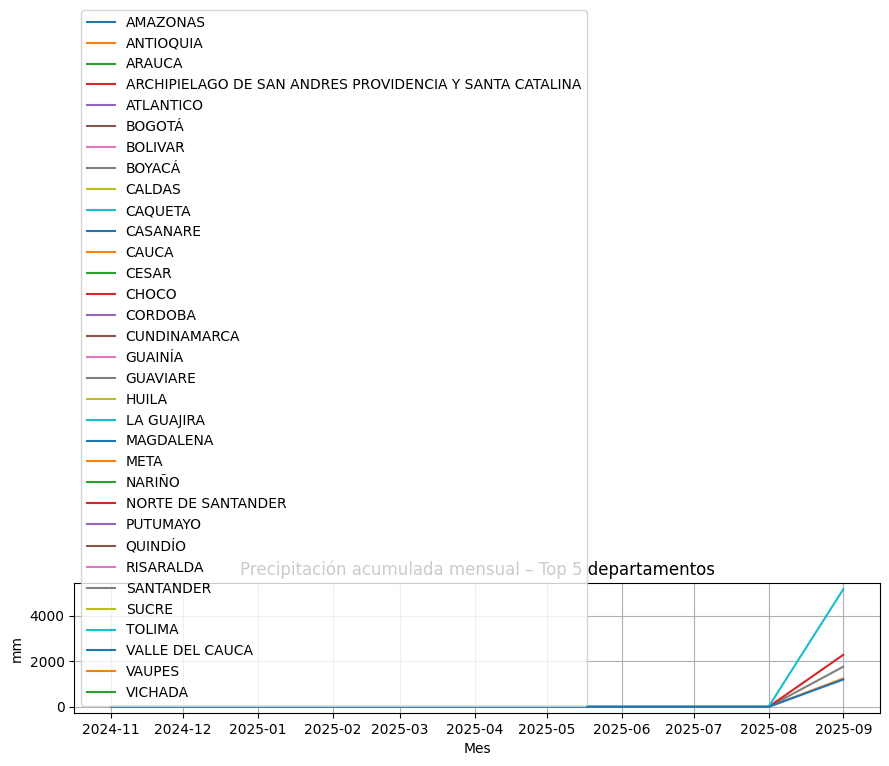

In [11]:
# Muestra el top 5 departamentos por precipitación total en el periodo
top_dep = acc_mes_depto.groupby("Departamento")["ValorObservado"].sum().nlargest(5).index
acc_top = acc_mes_depto[acc_mes_depto["Departamento"].isin(top_dep)]

plt.figure()
for dep, ddep in acc_top.groupby("Departamento"):
    ddep = ddep.sort_values("fecha_mes")
    plt.plot(ddep["fecha_mes"], ddep["ValorObservado"], label=dep)
plt.legend()
plt.title("Precipitación acumulada mensual – Top 5 departamentos")
plt.xlabel("Mes")
plt.ylabel("mm")
plt.tight_layout()
plt.show()

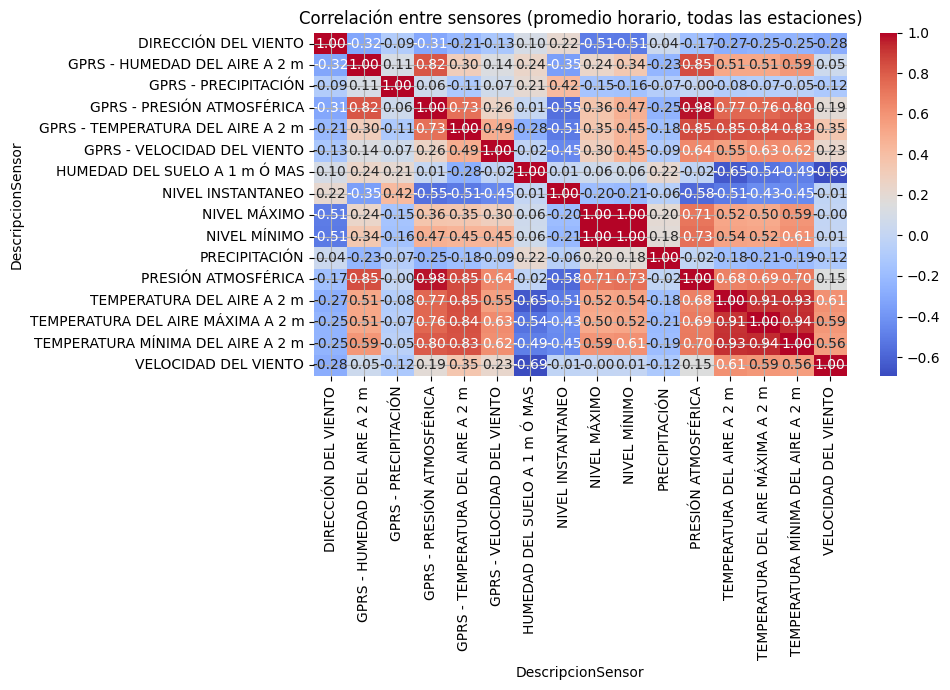

In [12]:
g = (
    df.set_index("FechaObservacion")
      .groupby("DescripcionSensor")["ValorObservado"]
      .resample("1H").mean()
      .unstack(0)
      .sort_index()
)

# descarta sensores con pocos datos
g = g.loc[:, g.count() >= 50]
corr = g.corr(min_periods=30)

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre sensores (promedio horario, todas las estaciones)")
plt.tight_layout()
plt.show()

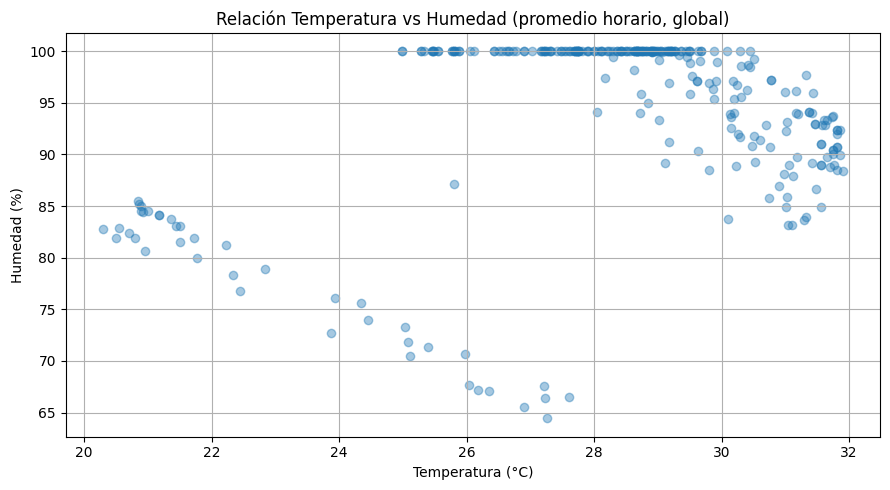

In [13]:
# Construye un panel alineado por hora con solo esas dos columnas
panel = (
    df[df["DescripcionSensor"].str.contains("TEMPERATURA|HUMEDAD", case=False, na=False)]
      .set_index("FechaObservacion")
      .groupby("DescripcionSensor")["ValorObservado"]
      .resample("1H").mean().unstack(0)
)

# intenta encontrar las columnas por nombre
col_temp = [c for c in panel.columns if "TEMPERATURA" in c.upper()]
col_hum = [c for c in panel.columns if "HUMEDAD" in c.upper()]
if col_temp and col_hum:
    XY = panel[[col_temp[0], col_hum[0]]].dropna()
    plt.figure()
    plt.scatter(XY[col_temp[0]], XY[col_hum[0]], alpha=0.4)
    plt.xlabel("Temperatura (°C)")
    plt.ylabel("Humedad (%)")
    plt.title("Relación Temperatura vs Humedad (promedio horario, global)")
    plt.tight_layout()
    plt.show()

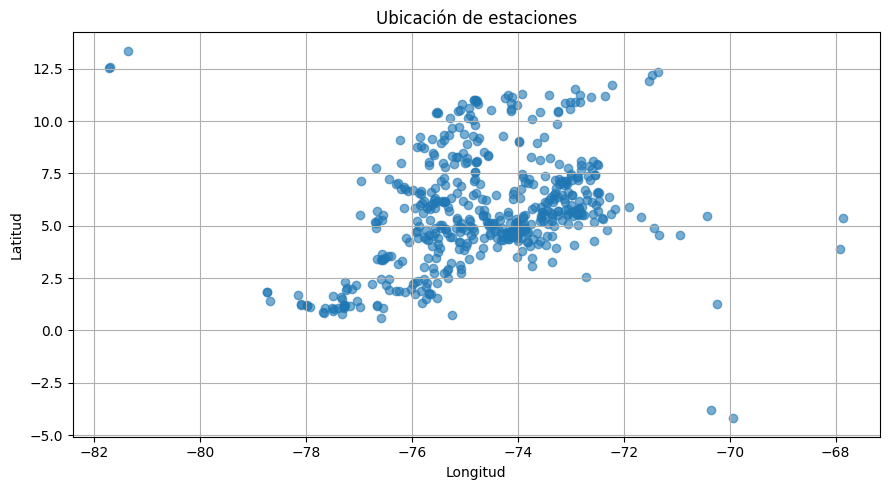

In [14]:
# Una marca por estación (toma la última lat/lon por nombre de estación)
pos = df.groupby("NombreEstacion")[["Latitud", "Longitud"]].last().dropna()
plt.figure()
plt.scatter(pos["Longitud"], pos["Latitud"], alpha=0.6)
plt.title("Ubicación de estaciones")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show()

In [15]:
# Reglas simples (ajusta límites si quieres)
anoms = []

# Humedad fuera de [0,100]
hum_all = df[df["DescripcionSensor"].str.contains("HUMEDAD", case=False, na=False)]
anoms.append(hum_all[~hum_all["ValorObservado"].between(0,100)])

# Temperatura fuera de [-15, 50] °C
tmp_all = df[df["DescripcionSensor"].str.contains("TEMPERATURA", case=False, na=False)]
anoms.append(tmp_all[~tmp_all["ValorObservado"].between(-15,50)])

# Viento negativo o > 60 m/s
wind_all = df[df["DescripcionSensor"].str.contains("VIENTO", case=False, na=False)]
anoms.append(wind_all[(wind_all["ValorObservado"] < 0) | (wind_all["ValorObservado"] > 60)])

# Presión fuera de [850, 1050] hPa
pres_all = df[df["DescripcionSensor"].str.contains("PRESIÓN", case=False, na=False)]
anoms.append(pres_all[~pres_all["ValorObservado"].between(850,1050)])

anomalias = pd.concat(anoms, ignore_index=True) if anoms else pd.DataFrame()
print("\n--- Anomalías detectadas (primeras 10) ---")
print(anomalias[["FechaObservacion","NombreEstacion","DescripcionSensor","ValorObservado"]].head(10))



--- Anomalías detectadas (primeras 10) ---
     FechaObservacion             NombreEstacion     DescripcionSensor  \
0 2025-09-01 03:30:00        AEROPUERTO SAN LUIS  DIRECCIÓN DEL VIENTO   
1 2025-09-01 03:50:00                     AYAPEL  DIRECCIÓN DEL VIENTO   
2 2025-09-01 03:50:00       AEROPUERTO EL EDEN -  DIRECCIÓN DEL VIENTO   
3 2025-09-01 03:20:00        AEROPUERTO SAN LUIS  DIRECCIÓN DEL VIENTO   
4 2025-09-01 04:00:00                    URUMITA  DIRECCIÓN DEL VIENTO   
5 2025-09-01 23:10:00        AEROPUERTO LA NUBIA  DIRECCIÓN DEL VIENTO   
6 2025-09-01 03:30:00                    URUMITA  DIRECCIÓN DEL VIENTO   
7 2025-09-01 04:20:00        AEROPUERTO LA NUBIA  DIRECCIÓN DEL VIENTO   
8 2025-09-01 03:20:00  AEROPUERTO ALM. PADILLA -  DIRECCIÓN DEL VIENTO   
9 2025-09-01 04:00:00                     AYAPEL  DIRECCIÓN DEL VIENTO   

   ValorObservado  
0           330.2  
1           268.0  
2           263.0  
3           230.8  
4           180.0  
5           150.0  
6


--- Top 10 estaciones más lluviosas (mm) ---
NombreEstacion
HATICO DE LOS INDIOS     5175.0
SAN JOSE PALMAR          1628.1
PISBA                    1457.7
AEROPUERTO LAS FLORES    1095.3
RIO IRO                   574.9
CENTENARIO HACIENDA       208.6
TRES ESQUINAS             167.8
HACIENDA TUNEZ            138.8
MUTATA                    124.0
BEIRUT                    119.6
Name: ValorObservado, dtype: float64


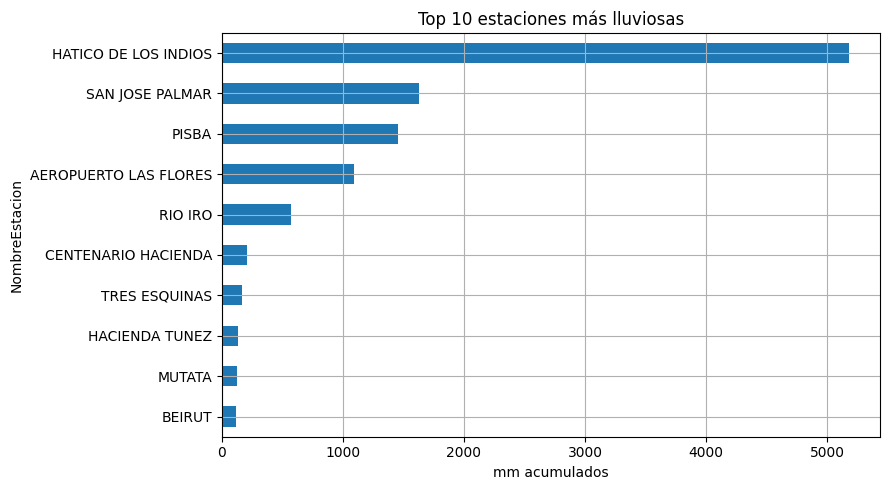

In [16]:
# Top 10 estaciones más lluviosas (suma de precipitación total en el periodo)
if not prec.empty:
    lluvia_est = prec.groupby("NombreEstacion")["ValorObservado"].sum().sort_values(ascending=False).head(10)
    print("\n--- Top 10 estaciones más lluviosas (mm) ---")
    print(lluvia_est.round(1))
    plt.figure()
    lluvia_est.sort_values().plot(kind="barh")
    plt.title("Top 10 estaciones más lluviosas")
    plt.xlabel("mm acumulados")
    plt.tight_layout()
    plt.show()